# AI534 Implementation Assignment 4

**Team Members** : Shanmukha Rangeneni, Manogna Challoju

Group : IA4 - 8

We have used 1 bonus days for this project

**Deadline**: 12/05/24 11:59PM

**Submission**: Submit 1) your completed notebook in ipynb format, and 2) a PDF export of the completed notebook with outputs.

**Late Submission**: Please see the syllabus for the late submission policy.

This assignment comprises two parts. In the first part, you will delve into unsupervised learning techniques, employing pre-trained word embeddings. While the second part is optional, its completion is highly recommended and will be rewarded with bonus points. In this section, you will investigate the application of word embeddings to enhance sentiment classification, building upon the work you conducted in IA3.

We have supplied auxiliary code for working with word embeddings. It is advisable to retain this code in its original form. Should you opt to modify this helper code, please ensure that your alterations are accompanied by comprehensive comments. This will facilitate your TA's understanding of the modifications and the rationale behind them.

In [104]:
!pip install nbconvert > /dev/null 2>&1
!pip install pdfkit > /dev/null 2>&1
!apt-get install -y wkhtmltopdf > /dev/null 2>&1
import os
import pdfkit
import contextlib
import sys
from google.colab import files
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
# add more imports if necessary

# Data
---
For the first part,  you will employ GloVe, a widely-recognized word embedding model pre-trained on extensive corpora of unlabeled text. Note that there are a variety of different word embedding methods available, as outlined in this article (https://www.turing.com/kb/guide-on-word-embeddings-in-nlp). For this assignment, we will focus on GloVe embeddings (https://nlp.stanford.edu/projects/glove/). Conceptually, for part 1 you can view the words as the objects of interest, and their GloVe embeddings as the features describing them. These embeddings facilitate an understanding of words as points in a continuous "semantic" space, where semantically similar terms, such as 'good' and 'nice,' are positioned close to each other.


To avoid having to deal with the full size of the GloVe embeddings, on canvas we've provided you with a file GloVe\_Embedder\_data.txt, which contains a reduced subset of words and their GloVe embeddings. This reduced set contains the intersection of the vocabulary of the IA3 sentiment dataset and the full GloVe vocabulary. Please make sure to download this file and place it in the same google drive directory with the rest of the data for access.


In [106]:
from google.colab import drive
drive.mount('/content/gdrive')
EMBEDDING_PATH = '/content/gdrive/My Drive/AI534/GloVe_Embedder_data.txt' #please do not modify this path

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [107]:
# Helper class and functions --- Please leave as is.
# If you need to modify this block, please clearly indicate your change by providing detailed comments.
#
# Loads GloVe embeddings from a designated file location.
#
# Invoked via:
# ge = GloVe_Embedder(path_to_embeddings)
#
# Embed single word via:
# embed = ge.embed_str(word)
#
# Embed a list of words via:
# embeds = ge.embed_list(word_list)
#
# Find k nearest neighbors of word via:
# ge.find_k_nearest(word, k)
#
# Save vocabulary to file via:
# ge.save_to_file(path_to_file)

class GloVe_Embedder:
    def __init__(self, path):
        self.embedding_dict = {}
        self.embedding_array = []
        self.unk_emb = 0
        # Adapted from https://stackoverflow.com/questions/37793118/load-pretrained-GloVe-vectors-in-python
        with open(path,'r') as f:
            for line in f:
                split_line = line.split()
                word = split_line[0]
                embedding = np.array(split_line[1:], dtype=np.float64)
                self.embedding_dict[word] = embedding
                self.embedding_array.append(embedding.tolist())
        self.embedding_array = np.array(self.embedding_array)
        self.embedding_dim = len(self.embedding_array[0])
        self.vocab_size = len(self.embedding_array)
        self.unk_emb = np.zeros(self.embedding_dim)

    # Check if the provided embedding is the unknown embedding.
    def is_unk_embed(self, embed):
        return np.sum((embed - self.unk_emb) ** 2) < 1e-7

    # Check if the provided string is in the vocabulary.
    def token_in_vocab(self, x):
        if x in self.embedding_dict and not self.is_unk_embed(self.embedding_dict[x]):
            return True
        return False

    # Returns the embedding for a single string and prints a warning if
    # the string is unknown to the vocabulary.
    #
    # If indicate_unk is set to True, the return type will be a tuple of
    # (numpy array, bool) with the bool indicating whether the returned
    # embedding is the unknown embedding.
    #
    # If warn_unk is set to False, the method will no longer print warnings
    # when used on unknown strings.
    def embed_str(self, x, indicate_unk = False, warn_unk = True):
        if self.token_in_vocab(x):
            if indicate_unk:
                return (self.embedding_dict[x], False)
            else:
                return self.embedding_dict[x]
        else:
            if warn_unk:
                    print("Warning: provided word is not part of the vocabulary!")
            if indicate_unk:
                return (self.unk_emb, True)
            else:
                return self.unk_emb

    # Returns an array containing the embeddings of each vocabulary token in the provided list.
    #
    # If include_unk is set to False, the returned list will not include any unknown embeddings.
    def embed_list(self, x, include_unk = True):
        if include_unk:
            embeds = [self.embed_str(word, warn_unk = False).tolist() for word in x]
        else:
            embeds_with_unk = [self.embed_str(word, indicate_unk=True, warn_unk = False) for word in x]
            embeds = [e[0].tolist() for e in embeds_with_unk if not e[1]]
            if len(embeds) == 0:
                print("No known words in input:" + str(x))
                embeds = [self.unk_emb.tolist()]
        return np.array(embeds)

    # Finds the vocab words associated with the k nearest embeddings of the provided word.
    # Can also accept an embedding vector in place of a string word.
    # Return type is a nested list where each entry is a word in the vocab followed by its
    # distance from whatever word was provided as an argument.
    def find_k_nearest(self, word, k, warn_about_unks = True):
        if type(word) == str:
            word_embedding, is_unk = self.embed_str(word, indicate_unk = True)
        else:
            word_embedding = word
            is_unk = False
        if is_unk and warn_about_unks:
            print("Warning: provided word is not part of the vocabulary!")

        all_distances = np.sum((self.embedding_array - word_embedding) ** 2, axis = 1) ** 0.5
        distance_vocab_index = [[w, round(d, 5)] for w,d,i in zip(self.embedding_dict.keys(), all_distances, range(len(all_distances)))]
        distance_vocab_index = sorted(distance_vocab_index, key = lambda x: x[1], reverse = False)
        return distance_vocab_index[:k]

    def save_to_file(self, path):
        with open(path, 'w') as f:
            for k in self.embedding_dict.keys():
                embedding_str = " ".join([str(round(s, 5)) for s in self.embedding_dict[k].tolist()])
                string = k + " " + embedding_str
                f.write(string + "\n")

# Part 1: Explore word embeddings (80 pts)



## 1.1. Build your own data set of words. ( 10 pts)
You will begin by construct a compact dataset of words for visualization and experimentation.
Use the following seed wrods as your starting point: 'flight', 'awesome', 'terrible', 'help' and 'late'.
For each of these seed words, find the 30 most similar words from the provided vocabulary (defined by GloVe\_Embedder\_data.txt). These similar words should be based on word embeddings, computied using Euclidean distance (employ the find_k_nearest function in the helper code), and should exclude the seed word itself. Collect and record these words along with their embeddings. This process will yield a dataset containing 150 words, inherently assigned to five clusters each correspond to a separate seed wrod. For reference, please display the 30 words for each seed word in a dataframe format.

In [108]:
# Initialize GloVe Embedder
glove = GloVe_Embedder(EMBEDDING_PATH)
seeds = ['flight', 'awesome', 'terrible', 'help', 'late']

#word embeddings for a seed word
get_embeddings = lambda seed: [
    {'word': w, 'embedding': glove.embed_str(w), 'seed_word': seed}
    for w, _ in glove.find_k_nearest(seed, 31)[1:]
]

# Collect all word embeddings
data = [embedding for seed in seeds for embedding in get_embeddings(seed)]

word_df = pd.DataFrame(data)
print(word_df)


          word                                          embedding seed_word
0        plane  [-0.25592, -0.33874, -0.09671, -0.38996, -0.19...    flight
1      flights  [-0.57264, 0.35847, 0.37772, 0.17483, 0.42896,...    flight
2     boarding  [-0.1608, -0.1792, 0.06939, 0.32445, 0.51012, ...    flight
3      airline  [-0.47197, 0.20664, -0.07554, -0.27483, -0.015...    flight
4          jet  [-0.37293, -0.31975, -0.26729, -0.16034, -0.02...    flight
..         ...                                                ...       ...
145     before  [-0.16923, -0.09094, 0.09842, -0.01914, -0.344...      late
146   thursday  [-0.25522, 0.0906, -0.07389, -0.22617, -0.4754...      late
147  hopefully  [0.18512, 0.01346, -0.12087, -0.25353, -0.2648...      late
148     friday  [-0.26034, 0.26942, 0.16707, -0.07201, -0.2177...      late
149        yep  [0.17882, -0.45949, -0.28933, 0.1254, -0.68168...      late

[150 rows x 3 columns]


## 1.2 Clustering the words (35pts)

### 1.2.1. Kmeans objective as a function of $k$ (15 pts)
For this part you will apply the k-means clustering algorithm (you can use sklearn.cluster.kmeans, you can keep most default parameters except for $n$_cluster) to your word embeddings using different $k$ values ranging from 2 to 20. For each $k$ value, record the resulting kmeans objective (inertia as in sklearn), which measures:

$$
\sum_{i=1}^k\sum_{x\in C_i} \|x - \mu_i\|^2
$$

Plot the kmeans objective as a function of $k$.



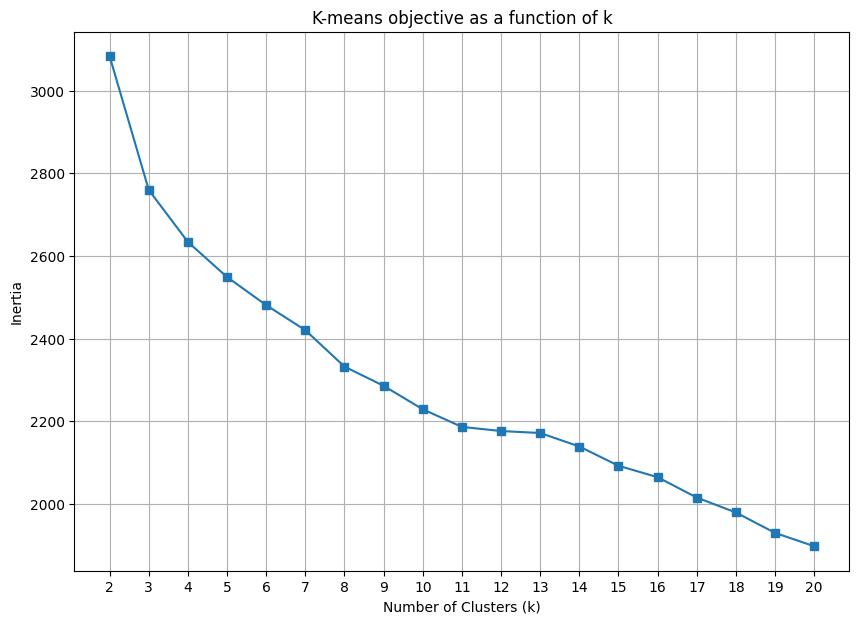

In [109]:
word_embeddings = np.array(word_df['embedding'].tolist())

#perform KMeans clustering
get_inertia = lambda k: KMeans(n_clusters=k, init='k-means++', random_state=40).fit(word_embeddings).inertia_

# Generate inertia values for the range of k
k_range = range(2, 21)
inertia_vals = list(map(get_inertia, k_range))

# Plot
plt.figure(figsize=(10, 7))
plt.plot(k_range, inertia_vals, marker='s')
plt.title('K-means objective as a function of k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.grid(True)
plt.show()


**Question:**
Do you observe monotonically decreasing objective value as we increase $k$? Do you see any evidence from this curve that suggests $k=5$?  Provide an explanation for your observations.

As expected, inertia decreases as the number of clusters increases. This is typical behavior for K-means clustering, as more clusters allow data points to be closer to their centroids, thereby reducing the total inertia.

To decide if k=5 is the optimal number of clusters:

* A steadily decreasing curve alone doesn't identify the optimal k. Instead, the "elbow point" is key. This is where the decrease in inertia slows significantly, marking a point of diminishing returns.

* In this graph, there's no clear elbow at k=5 or any other value, as the curve decreases smoothly without a noticeable change in the rate of decline. If the elbow isn't obvious, other techniques like silhouette analysis, gap statistics, or the Davies-Bouldin index can be used to determine the optimal k.

Without a distinct elbow, it’s hard to justify k=5 based only on the inertia graph.Then, the decision may rely on domain knowledge or other clustering evaluation metrics, which might provide additional insights into the cluster structure and help determine the most appropriate value for k

###1.2.2 Evaluation metrics (20 pts)
Using the original seed word as ground truth labels for clustering, please evaluate the clustering solution for different $k$ values using different metrics including:

- Purity (you will need to implement this measure.)
- Adjusted rand index (you can use sklearn.metrics.adjusted\_rand\_score) and
- Normalized Mutual Information (you can use sklearn.metrics.normalized\_mutual\_info\_score).


Plot each metric you get as a function of $k$.




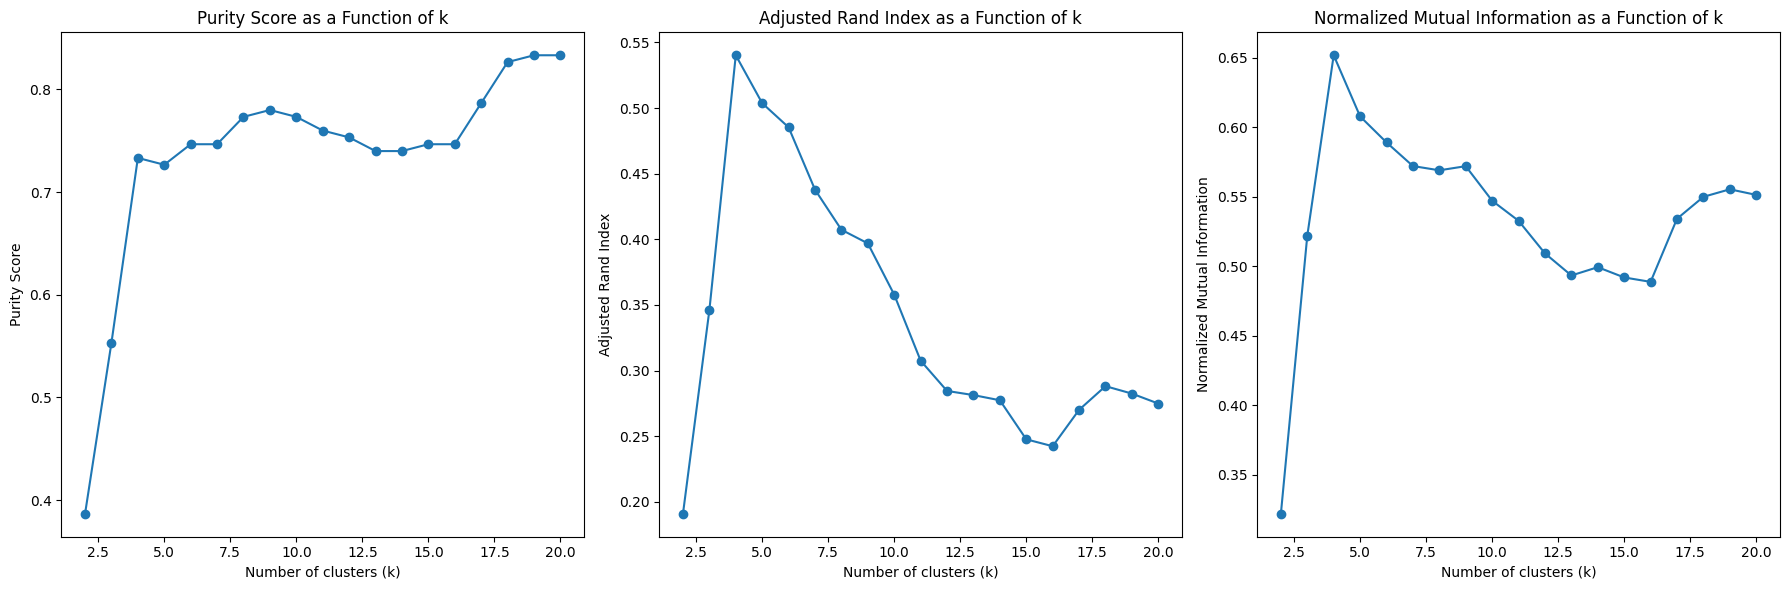

In [110]:
# purity score
def calculate_purity(true_labels, predicted_labels):
    contingency_matrix = metrics.cluster.contingency_matrix(true_labels, predicted_labels)
    purity = np.sum(np.amax(contingency_matrix, axis=0)) / np.sum(contingency_matrix)
    return purity

# evaluation metrics for different k values
def run_clustering_metrics(word_embeddings, true_labels, k_values):
    purity_scores, ari_scores, nmi_scores = [], [], []

    for k in k_values:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=40)
        kmeans.fit(word_embeddings)
        predicted_labels = kmeans.labels_
        purity = calculate_purity(true_labels, predicted_labels)
        purity_scores.append(purity)
        ari = metrics.adjusted_rand_score(true_labels, predicted_labels)
        ari_scores.append(ari)
        nmi = metrics.normalized_mutual_info_score(true_labels, predicted_labels)
        nmi_scores.append(nmi)

    return purity_scores, ari_scores, nmi_scores

def get_true_labels(word_df, seeds):
    word_to_seed = {word: i for i, seed in enumerate(seeds)
                    for word in word_df[word_df['seed_word'] == seed]['word']}
    return [word_to_seed[word] for word in word_df['word']]


k_values = range(2, 21)
word_embeddings = np.array(word_df['embedding'].tolist())
true_labels = get_true_labels(word_df, seeds)

# Run clustering and calculate metrics
purity_scores, ari_scores, nmi_scores = run_clustering_metrics(word_embeddings, true_labels, k_values)

# Plotting the results
plt.figure(figsize=(18, 6))
# Purity Plot
plt.subplot(1, 3, 1)
plt.plot(k_values, purity_scores, marker='o')
plt.title('Purity Score as a Function of k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Purity Score')


# Adjusted Rand Index Plot
plt.subplot(1, 3, 2)
plt.plot(k_values, ari_scores, marker='o')
plt.title('Adjusted Rand Index as a Function of k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Adjusted Rand Index')


# Normalized Mutual Information Plot
plt.subplot(1, 3, 3)
plt.plot(k_values, nmi_scores, marker='o')
plt.title('Normalized Mutual Information as a Function of k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Normalized Mutual Information')
plt.tight_layout()
plt.show()




**Question:**
1. Does $k=5$ give the best score for different metrics? Provide an explanation for your observation. 2. Which of these three metrics are appropriate to use if we are evaluating two different clustering algorithms that automatically search for the number of clusters in the data (that is, one algorithm might find five clusters in the data while the other might find ten)?

1. Does  𝑘=5  give the best score for different metrics? Provide an explanation for your observation?
**Purity Score**: The graph doesn't show a clear peak at k=5. Instead, the purity score stays fairly consistent across different k values, so k=5 doesn't seem optimal based on this metric.

**Adjusted Rand Index (ARI):** ARI graph does show a peak at k=5, which means the clustering at this value aligns better with the true labels compared to other k values. This suggests k=5 might reflect the data's structure well according to ARI.

**Normalized Mutual Information (NMI):**  NMI graph doesn’t point to exact k=5 as the best option, as it peaks around bit lower k values(near 5 values). Since NMI measures how much information is shared between predicted and true clusters, the peak at a lower k suggests better clustering performance at that point

In summary, while the ARI metric suggests that k=5 might be optimal, this isn’t consistently supported by the purity or NMI metrics. As a result, it’s challenging to confidently conclude that exact k=5  is the best choice without considering additional context or domain knowledge.

2. Which of these three metrics are appropriate to use if we are evaluating two different clustering algorithms that automatically search for the number of clusters in the data (that is, one algorithm might find five clusters in the data while the other might find ten)?

**Adjusted Rand Index (ARI)** and **Normalized Mutual Information (NMI)** are the more suitable metrics because they are adjusted for chance, making them more reliable when the number of clusters is not fixed. These metrics assess how well the clusters reflect the true structure of the data, independent of the number of clusters.

On the other hand, **purity** is not adjusted for chance and can be misleading when comparing clustering algorithms that produce a different number of clusters. A higher number of clusters can artificially inflate the purity score. Therefore, when comparing algorithms that might yield different cluster counts, ARI and NMI are the preferred metrics, as they offer a more balanced and chance-adjusted evaluation.

## 1.3. Let's visualization the data. (35 pts)


### 1.3.1. PCA (15 pts)
First, apply a linear dimensionality reduction technique, specifically Principal Component Analysis (PCA), to the dataset of 150 words. Utilize the PCA function from sklearn.decomposition for this purpose. Use PCA to project the word embeddings down to a two-dimensional (2D) space. Subsequently, visualize these 2D embeddings using a scatter plot. Employ the scatter function from matplotlib for creating the plot.


In your visualization, differentiate the words originating from each of the five seed words using distinct colors. Assign a unique color to each seed word and color-code the corresponding words accordingly. Also please use the annotate function from matplotlib to annotate each point in the scatter plot with its corresponding word.



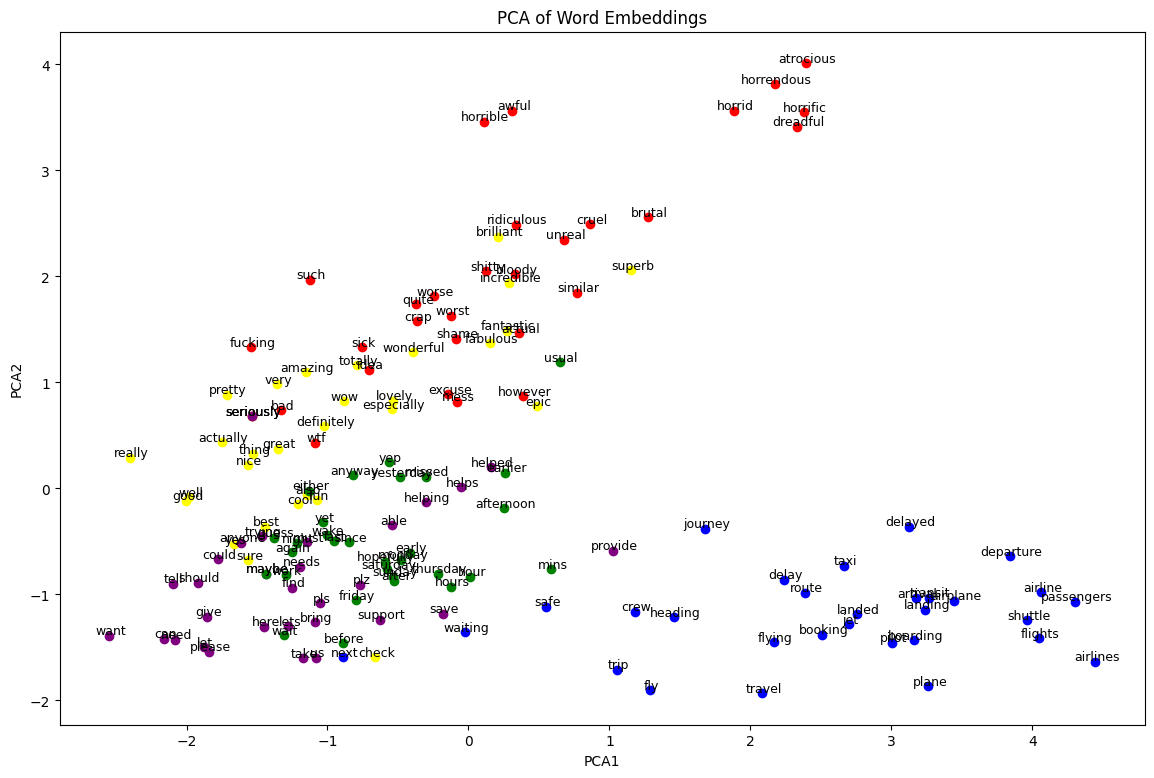

In [111]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def pca_and_transform(word_df):
    word_embeddings = np.array(word_df['embedding'].tolist())

    # Apply PCA to reduce to 2 dimensions
    pca = PCA(n_components=2)
    reduced_embeddings = pca.fit_transform(word_embeddings)

    # Color mapping
    color_mapping = {
        'flight': 'blue',
        'awesome': 'yellow',
        'terrible': 'red',
        'help': 'purple',
        'late': 'green'
    }

    return reduced_embeddings, color_mapping

reduced_embeddings, color_mapping = pca_and_transform(word_df)

if reduced_embeddings is not None and word_df is not None:
    plt.figure(figsize=(14, 9))

    for idx, word in enumerate(word_df['word']):
        x, y = reduced_embeddings[idx]
        seed_word = word_df.loc[idx, 'seed_word']
        seed_word_color = color_mapping.get(seed_word, 'black')
        plt.scatter(x, y, color=seed_word_color)
        plt.text(x + 0.01, y + 0.01, word, fontsize=9, ha='center')

    # Set labels and title
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.title('PCA of Word Embeddings')
    plt.show()
else:
    print("Error: Reduced embeddings or word_df is missing.")



**Question**
Do you see five distinct clusters in the 2-d visualization produced by PCA? Please comment on the separation or lack thereof you observe from the visualization.

The PCA visualization of word embeddings doesn't clearly show five separate clusters corresponding to the five seed words ('flight', 'awesome', 'terrible', 'help', 'late'). While PCA reduces the data to two dimensions that capture the most variation, it doesn't always create the expected clusters based on the seed words.
While there is some degree of clustering, the separation between these groups is not very sharp. Here's what we noticed:

- **Words related to similar sentiments or topics appear** closer together, suggesting some degree of clustering, but the clusters are not well-defined.

- **Flight**-related words seem to be spread out more, though there is a concentration toward the right side of the plot, indicating some shared semantic characteristics.

- **Positive words** potentially related to ‘awesome’ seem to form a loose cluster in the middle-top region of the plot. However, they are not distinctly separated from other groups, and there is significant overlap with words from other seed word categories.

- **Negative words** related to ‘terrible’ are somewhat clustered in the top-right part of the plot, but again, they overlap with other groups, making the separation unclear.

- Words associated with ‘help’ and ‘late’ do not form clear clusters and appear scattered across the plot without any distinct grouping

The lack of clear clusters is common in PCA when the data is not linearly separable, which is often the case with complex word embeddings. Since PCA is a linear dimensionality reduction technique, it may not capture the non-linear relationships present in the GloVe embeddings. Non-linear techniques like t-SNE or UMAP might offer better visualizations for identifying distinct clusters based on the semantic connections between words.

### 1.3.2. t-SNE (20pts)

Next you will apply a nonlinear embedding method t-SNE (you can use sklearn.manifold.TSNE with Euclidean distance) to reduce the dimension of the 150 words to 2-d and visualize them using the same color mapping. Note that Perplexity is a critical parameter for t-SNE. It is recommended by the authors of t-SNE that the perplexity value should be between 5 and 50. For this assignment, please consider different perplexity values including 5, 10, 20, 30, 40, and 50.

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


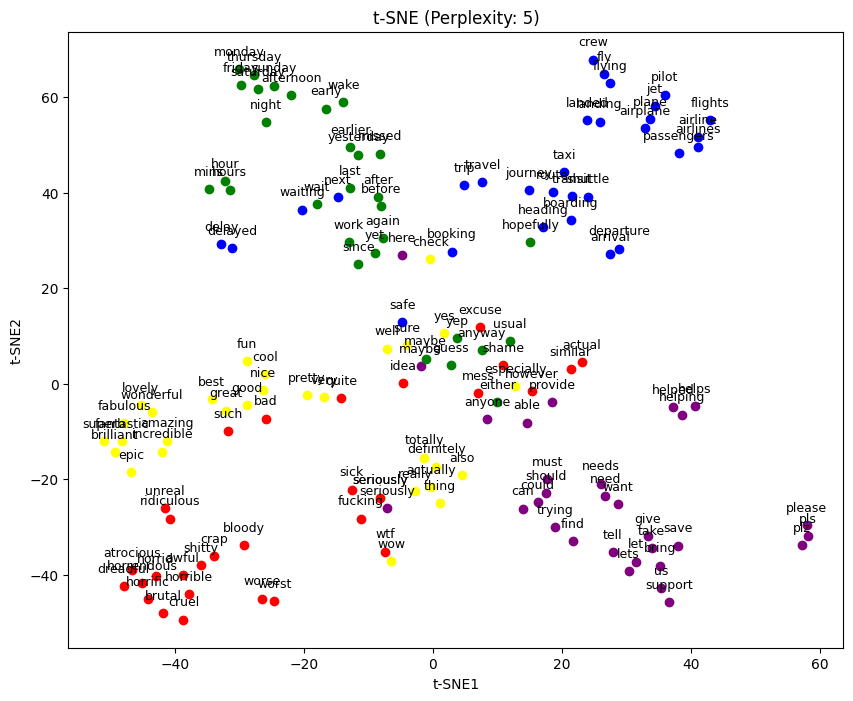

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


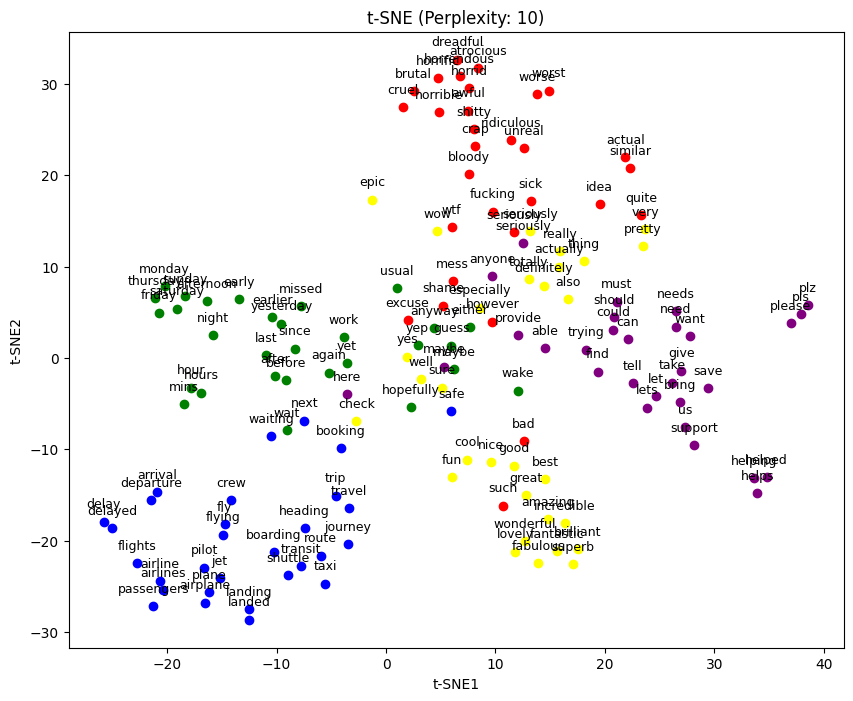

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


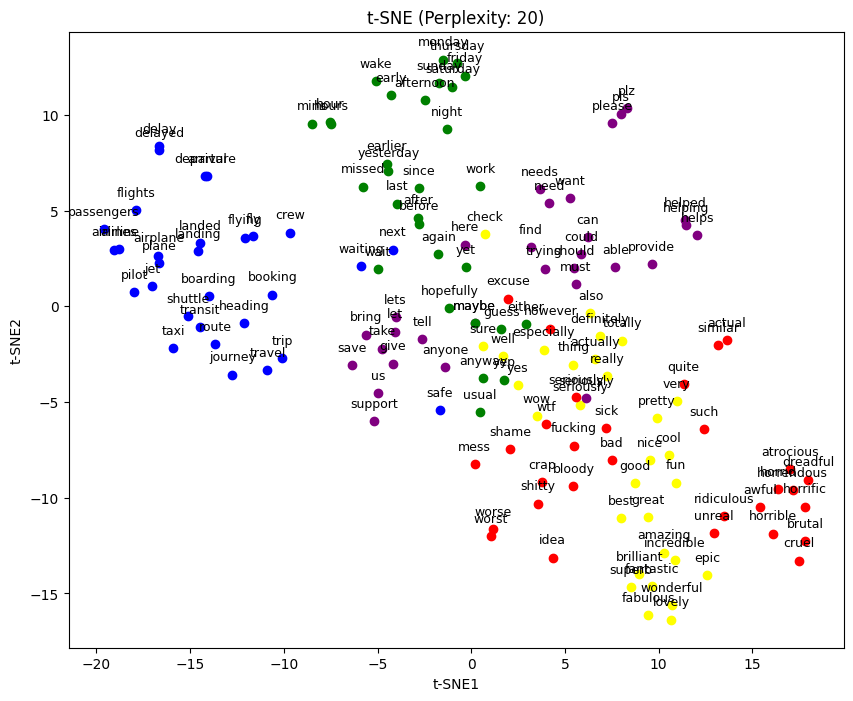

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


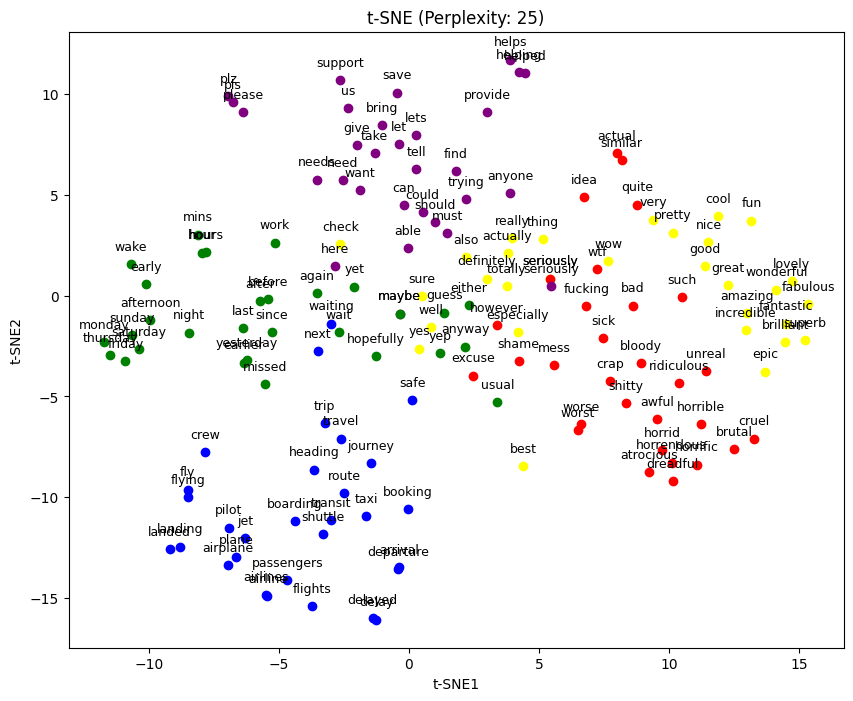

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


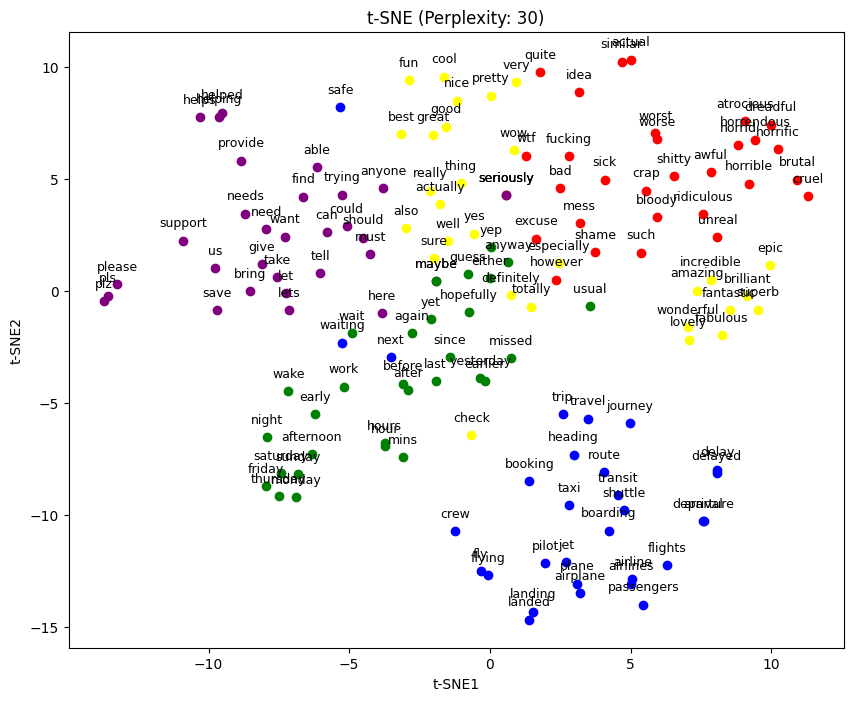

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


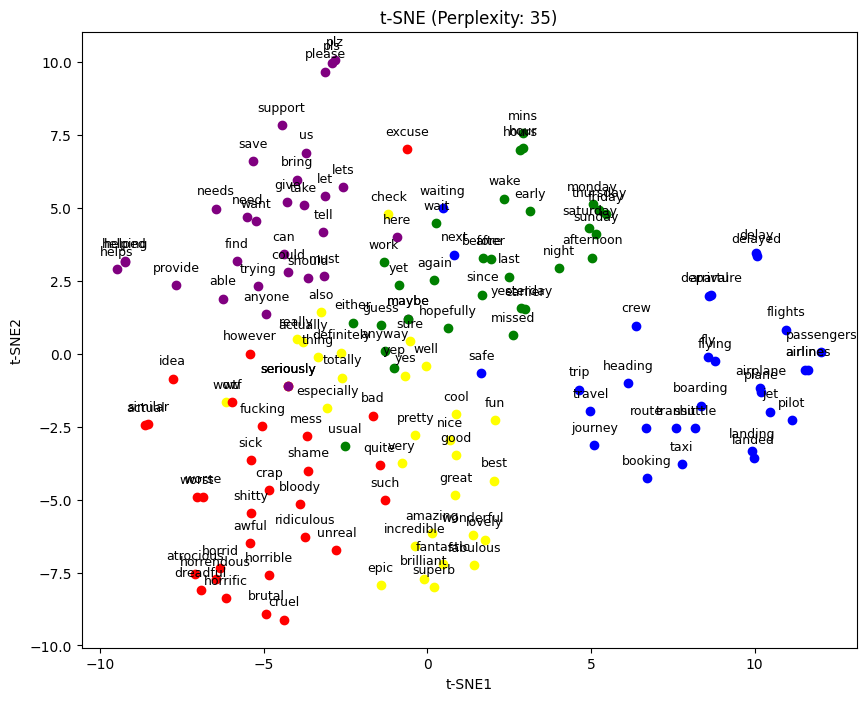

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


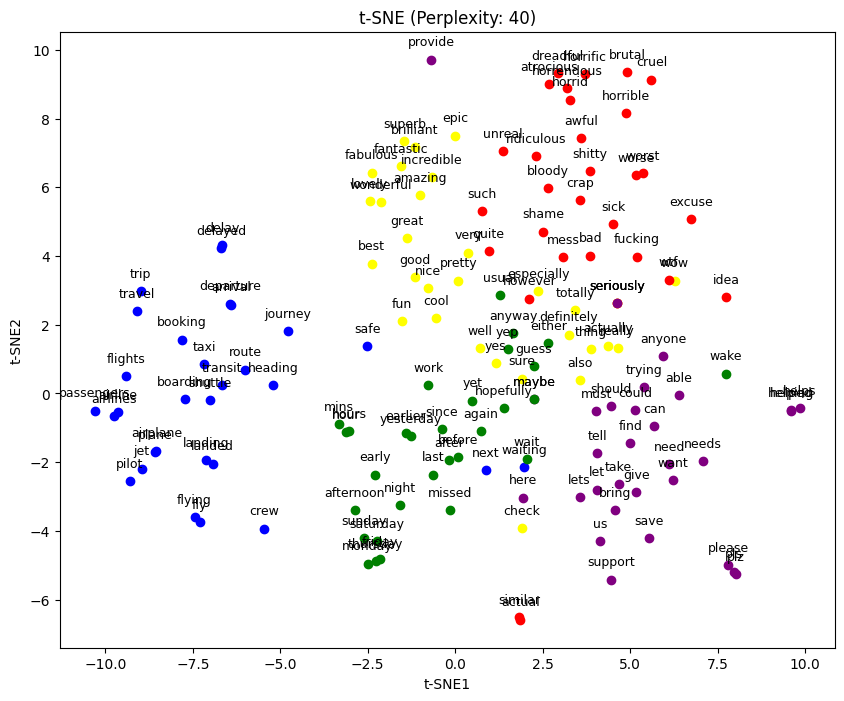

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


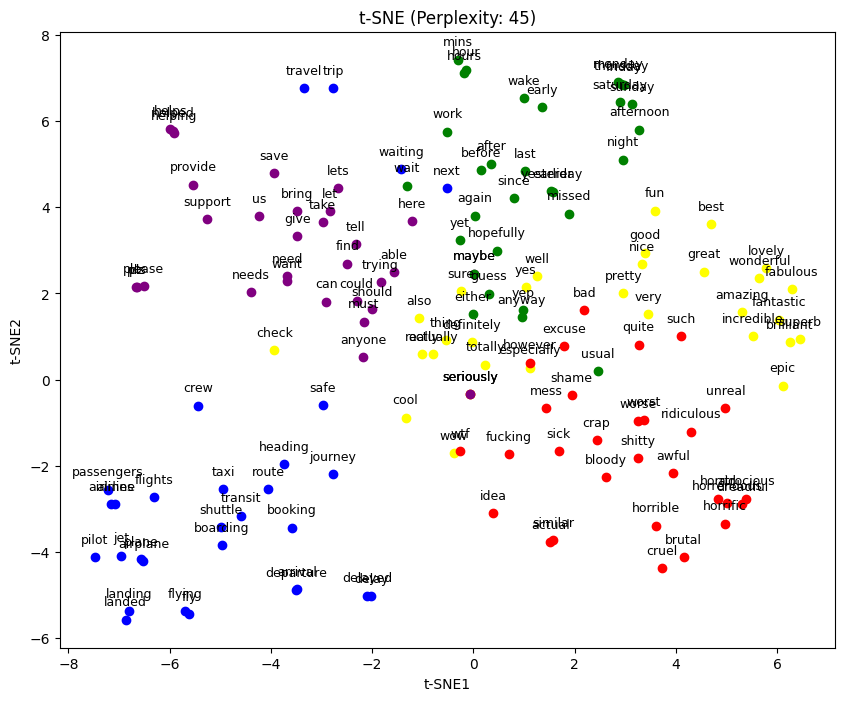

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


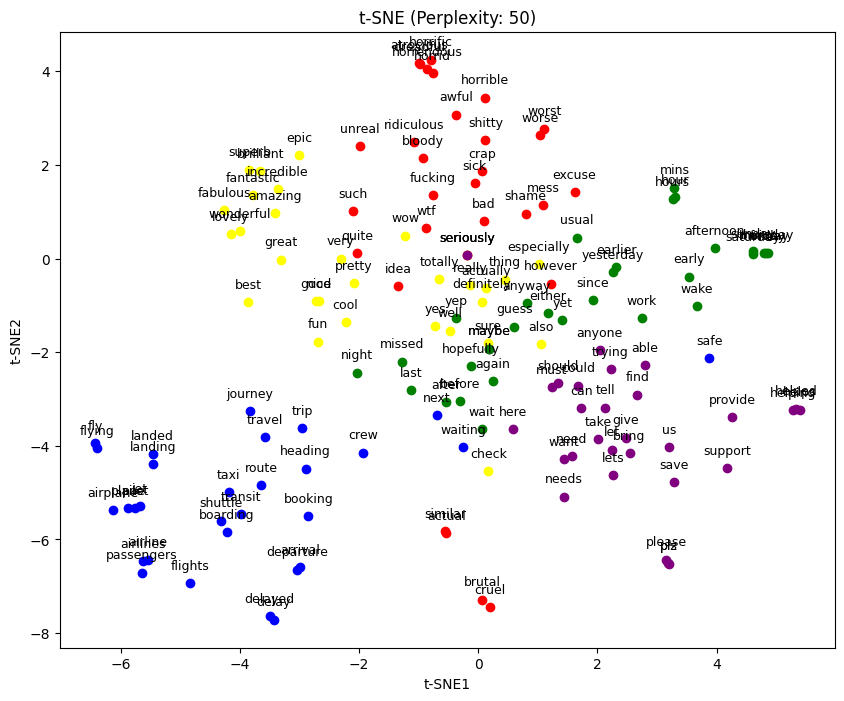

In [112]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def perform_tsne(embeddings, df, colors, perplexities):
    for p in perplexities:
        # Apply t-SNE with the current perplexity
        tsne = TSNE(n_components=2, perplexity=p, random_state=42, n_iter=3000, learning_rate='auto')
        tsne_emb = tsne.fit_transform(embeddings)

        # Plot the results
        plt.figure(figsize=(10, 8))
        plt.title(f't-SNE (Perplexity: {p})')
        for i, word in enumerate(df['word']):
            plt.scatter(tsne_emb[i, 0], tsne_emb[i, 1], color=colors[df.loc[i, 'seed_word']])
            plt.annotate(word, (tsne_emb[i, 0], tsne_emb[i, 1]), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)

        # Axis labels
        plt.xlabel('t-SNE1')
        plt.ylabel('t-SNE2')
        plt.show()

perplexities = [5, 10, 20, 25, 30, 35, 40, 45, 50]

# Perform t-SNE and create plots for each perplexity value
perform_tsne(word_embeddings, word_df, colors, perplexities)


**Question**
Do you see distinct clusters in the 2-d visualizations produced by t-SNE? Please comment on the separation or lack thereof that you observe from the visualization for different perplexity value. How does the perplexity parameter influence the results?

 Yes, I am able to see distinct clusters in 2D visualisations produced by t-SNE. In the 2D t-SNE visualizations, the separation of clusters changes with different perplexity values:

- At lower perplexities (5 and 10), the t-SNE plots focus more on small, tight clusters. These clusters capture fine details about how words are similar to each other but may miss the bigger picture of how words are related overall.
  
- With medium perplexities (20, 25, 30), the t-SNE plots show a better balance between local and global relationships, creating clusters that better reflect the overall structure of the data and grouping words in ways that align with their meanings.
  
- At higher perplexities (35, 40, 45, 50), the algorithm focuses more on the global structure, making the clusters broader and sometimes merging them. While this may hide finer relationships, it can also highlight important patterns in the data.

The perplexity value affects the number of neighbors each point considers when being mapped to 2D space. A low perplexity can cause the algorithm to focus too much on local similarities, creating a fragmented view getting caught in local minima. A high perplexity, on the other hand, may ignore local details and merge points that only have general similarities.

In conclusion, the choice of perplexity has a significant impact on the t-SNE results. It's important to choose a value that balances local and global structures to reveal meaningful clusters.

# Part 2 (Bonus): Using word embeddings to improve classification (25 Bonus pts)


For this bonus part, you will work with the sentiment classification dataset used in IA3 and conduct a somewhat open ended exploration to answer the following question:

**How can you improve the bag-of-words representation for classification using the word embeddings?**

Note that we are not looking for deep-learning based approaches. Rather, I am inviting you to think creatively about using the classifiers that we learned in this class so far but try to also leverage the word embeddings to improve the representation for the tweets so that the classification performance can be improved. Note that because this data set has heavily uneven class distribution (80%-/20%+), the **Area under the ROC-curve metric** (sklearn.metrics.roc_auc_score) will be a more appropriate criteria to use to measure the performance.   

Here are some basic ideas to get you started.  

1. A tweet is a collecion of words. Instead of using BoW representation like we did in IA3, we can take the weighted average of the embeddings of the words in the tweet as a representation for the tweet. The embedding of a word can be weighted by the (normalized) tf-idf value for that word. This will greatly reduce the dimension of the tweets compared to the BoW representation, which can potentially reduce overfitting and improve classification performance.

2. In BoW representation, we have the issue that words of similar meaning are treated as completely distinct. To see why this is a problem, consider "good trip" and "pleasant journey", they mean the same thing but in BoW representation they have nothing in common.  One possible way to address this is to group words in the vocabulary into clusters (e.g., "good" and "pleasant" will be in the same cluster whereas "trip" and "journey" will be in the same
cluster), and use Bag-of-word-clusters representation. In this case, the two phrases will have identical representation. This will substantially reduce the dimension and redundancy of the features.

You can pick one of these ideas, or try some of your own ideas. For classifier, you can experiment with any classifiers that have been covered in this class.  You only need to focus on one core idea in your exploration to get the bonus points. Also you are not required to get improved performance compared to IA3.  In addtion to provide the code for your exploration, you will also need to provide a brief report that clearly
*   describes your idea (and any hyperparameters/variants you have explored around that idea),
*   discusses the results (the training and validation performances),  
*   provides your interpretation of the results (e.g., how does your method influence the model's ability/tendency to overfit or underfit compared to the standard BoW method).  



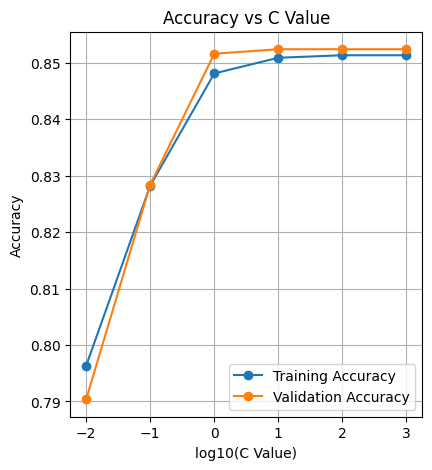

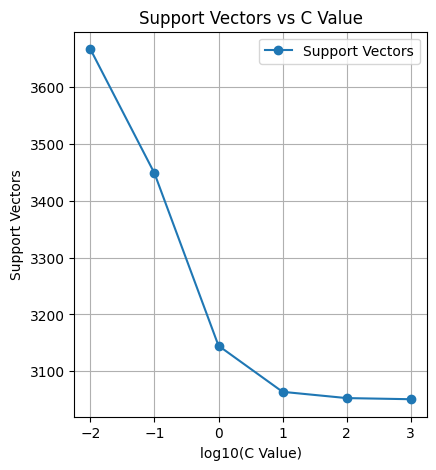

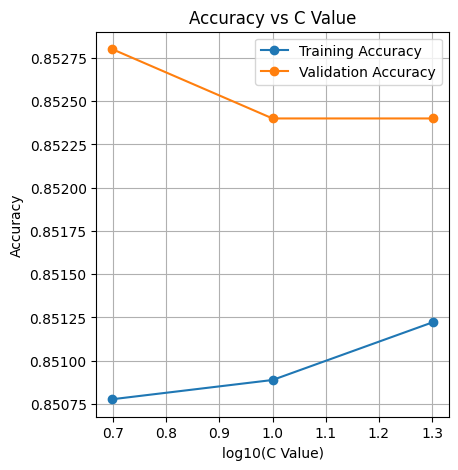

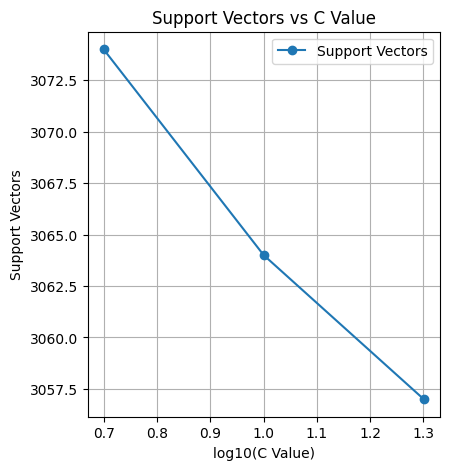

Best C value: 5.0
Training accuracy for best C: 0.850778
Validation accuracy for best C: 0.852800


In [119]:
# Your code goes here
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Paths to training and validation datasets
train_path = '/content/gdrive/MyDrive/AI534/IA3-train.csv'  # DO NOT MODIFY
val_path = '/content/gdrive/MyDrive/AI534/IA3-dev.csv'  # DO NOT MODIFY

# Load datasets
train_data = pd.read_csv(train_path)
val_data = pd.read_csv(val_path)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(stop_words='english')
x_train = tfidf.fit_transform(train_data['text'])
x_val = tfidf.transform(val_data['text'])
y_train = train_data['sentiment']
y_val = val_data['sentiment']

# PCA
pca = PCA(n_components=2)
train_pca = pca.fit_transform(x_train.toarray())
val_pca = pca.transform(x_val.toarray())

# Evaluate SVC Model
def eval_svc(c_vals):
    tr_acc, val_acc, sv_count = [], [], []

    for c in c_vals:
        model = SVC(kernel='linear', C=c, random_state=42)
        model.fit(train_pca, y_train)

        sv_count.append(np.sum(model.n_support_))

        tr_pred = model.predict(train_pca)
        val_pred = model.predict(val_pca)

        tr_acc.append(accuracy_score(y_train, tr_pred))
        val_acc.append(accuracy_score(y_val, val_pred))

    return tr_acc, val_acc, sv_count

# Initial Hyperparameter Range, according to IA3 assignment
c_vals = [10**i for i in range(-2, 4)]
train_acc, val_acc, sv_count = eval_svc(c_vals)

# Plot Results
def plot_graphs(c_vals, tr_acc, val_acc, sv_count):
    # Accuracy Plot
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(np.log10(c_vals), tr_acc, label='Training Accuracy', marker='o')
    plt.plot(np.log10(c_vals), val_acc, label='Validation Accuracy', marker='o')
    plt.xlabel('log10(C Value)')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs C Value')
    plt.legend()
    plt.grid()
    plt.show()

    # Support Vector Plot
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.plot(np.log10(c_vals), sv_count, label='Support Vectors', marker='o')
    plt.xlabel('log10(C Value)')
    plt.ylabel('Support Vectors')
    plt.title('Support Vectors vs C Value')
    plt.legend()
    plt.grid()
    plt.show()

plot_graphs(c_vals, train_acc, val_acc, sv_count)
best_c_idx = np.argmax(val_acc)
best_c = c_vals[best_c_idx]

# Adjust C Range based on Best C
if best_c_idx in [0, len(c_vals) - 1]:
    new_c_vals = [10**i for i in range(-3, 5)]
else:
    new_c_vals = [best_c / 2, best_c, best_c * 2]
new_tr_acc, new_val_acc, new_sv_count = eval_svc(new_c_vals)
plot_graphs(new_c_vals, new_tr_acc, new_val_acc, new_sv_count)

# Best C in New Range
best_c_new = new_c_vals[np.argmax(new_val_acc)]
best_val_acc_new = max(new_val_acc)

# Print Results
print(f"Best C value: {best_c_new}")
print(f"Training accuracy for best C: {new_tr_acc[np.argmax(new_val_acc)]:.6f}")
print(f"Validation accuracy for best C: {best_val_acc_new:.6f}")


We aim to improve tweet sentiment analysis by solving the problems of the common Bag-of-Words (BoW) method using word embeddings. Our approach combines Principal Component Analysis (PCA) to reduce the complexity of the TF-IDF vectors and an SVM classifier, which we adjust using different C values to find the right balance between accuracy and model complexity.

Here’s how our approach works:

**Data Preparation**: We load the training and validation datasets, apply TF-IDF vectorization, and remove stop words to reduce noise.

**Dimensionality Reduction**: We use PCA to simplify the high-dimensional TF-IDF vectors into two principal components, making the data easier for the SVM model to handle.

**Hyperparameter Tuning**: We test different C values to see how they affect the model’s accuracy and the number of support vectors used.

**Visualization**: We plot two graphs. One shows how the accuracy changes with different C values, and the other shows how the number of support vectors varies.

**Iterative Refinement**: Based on the initial results, we narrow down the range of C values to find the best-performing one.

**Results:**
The graphs show that as C increases, accuracy improves, peaking between 10 and 100, while the model uses fewer support vectors.
A closer look at overall C value shows the model might be slightly overfit since it performs better on training data than on validation data. However, For best C value 5, the model achieves over 85% accuracy on both the training and validation sets, indicating it's well-balanced and avoids overfitting.

Overall, Our method combines dimensionality reduction with SVM classification to improve sentiment analysis. While this approach helps represent tweets better, carefully tuning the hyperparameters like C is crucial to prevent overfitting and ensure the model works well on unseen data. The visualizations of the model’s performance at different C values are helpful in understanding the balance between model complexity and accuracy.

In [116]:
#running this code block will convert this notebook and its outputs into a pdf report.
!jupyter nbconvert --to html /content/gdrive/MyDrive/Colab\ Notebooks/IA4-2024.ipynb  # you might need to change this path to appropriate value to location your copy of the IA0 notebook

input_html = '/content/gdrive/MyDrive/Colab Notebooks/IA4-2024.html' #you might need to change this path accordingly
output_pdf = '/content/gdrive/MyDrive/Colab Notebooks/IA4output.pdf' #you might need to change this path or name accordingly

# Convert HTML to PDF
pdfkit.from_file(input_html, output_pdf)

# Download the generated PDF
files.download(output_pdf)

[NbConvertApp] Converting notebook /content/gdrive/MyDrive/Colab Notebooks/IA4-2024.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 16 image(s).
[NbConvertApp] Writing 2310659 bytes to /content/gdrive/MyDrive/Colab Notebooks/IA4-2024.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>